# OnomaCap Factor Conditioning — canonical Jamo + BF16

HTSAT→BART 구조를 유지하면서 audio와 6개 acoustic factor의 factor×time token에 독립적인 decoder cross-attention을 적용하고, 한국어 의성어를 `(초성 중성 [종성]?) *` 형식의 canonical Jamo 토큰으로 학습합니다. 초반에는 factor 경로만 학습하고, 이후 audio modality dropout을 점진적으로 낮춰 joint training으로 전환합니다. 이 노트북은 factor 추출, smoke test, 학습, 평가, teacher-forced 자모×factor attention 집계를 순서대로 실행합니다.

In [1]:
# 의존성 설치
%pip install -q transformers==4.36.2 tokenizers==0.15.2 "huggingface-hub<1.0" torchlibrosa==0.1.0 librosa==0.10.2.post1 ruamel.yaml==0.17.40 gdown==5.2.0 "kagglehub>=0.3.12" pycocoevalcap==1.2 "scikit-learn>=1.4,<1.7" "pandas>=2.1,<2.4" matplotlib seaborn tqdm loguru warmup-scheduler gensim

# 저장소 clone 및 WavCaps overlay 적용
import shutil
import subprocess
from pathlib import Path

ONOMAHOW_REPO = "https://github.com/youhan200203/OnomaHoW.git"
ONOMAHOW_REF = "working"
WAVCAPS_REPO = "https://github.com/XinhaoMei/WavCaps.git"
WAVCAPS_COMMIT = "a5a9649ce305d7fe82cfcf5d6a4a12f03df9ef1e"
ANNOTATION_REPO = "https://github.com/jspirit01/sound-to-onomatopoeia.git"

ONOMAHOW_DIR = Path("/content/OnomaHoW")
WAVCAPS_DIR = Path("/content/WavCaps")
ANNOTATION_DIR = Path("/content/sound-to-onomatopoeia")

for transient_dir in (ONOMAHOW_DIR, WAVCAPS_DIR, ANNOTATION_DIR):
    if transient_dir.exists():
        shutil.rmtree(transient_dir)

subprocess.run(
    ["git", "clone", "-q", "--depth", "1", "--branch", ONOMAHOW_REF, ONOMAHOW_REPO, str(ONOMAHOW_DIR)],
    check=True,
)
subprocess.run(["git", "clone", "-q", WAVCAPS_REPO, str(WAVCAPS_DIR)], check=True)
subprocess.run(
    ["git", "-C", str(WAVCAPS_DIR), "checkout", "--detach", "-q", WAVCAPS_COMMIT],
    check=True,
)
subprocess.run(["git", "clone", "-q", "--depth", "1", ANNOTATION_REPO, str(ANNOTATION_DIR)], check=True)

overlay_root = ONOMAHOW_DIR / "wavcaps_patch"
overlay_files = sorted(overlay_root.rglob("*.py"))
assert overlay_files, "wavcaps_patch overlay가 비어 있습니다."
for source in overlay_files:
    destination = WAVCAPS_DIR / source.relative_to(overlay_root)
    destination.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(source, destination)
    assert source.read_bytes() == destination.read_bytes()

helper_destination = WAVCAPS_DIR / "captioning/tools/jamo_preprocessing.py"
config_destination = WAVCAPS_DIR / "captioning/settings/onomacap_jamo.yaml"
factor_config_destination = WAVCAPS_DIR / "captioning/settings/onomacap_jamo_factor.yaml"
shutil.copy2(ONOMAHOW_DIR / "jamo_preprocessing.py", helper_destination)
shutil.copy2(ONOMAHOW_DIR / "configs/onomacap_jamo.yaml", config_destination)
shutil.copy2(ONOMAHOW_DIR / "configs/onomacap_jamo_factor.yaml", factor_config_destination)

checked_out_commit = subprocess.check_output(
    ["git", "-C", str(WAVCAPS_DIR), "rev-parse", "HEAD"], text=True
).strip()
assert checked_out_commit == WAVCAPS_COMMIT
print(f"WavCaps {checked_out_commit} + {len(overlay_files)} overlay files")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 12.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 152.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 123.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.1/260.1 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.7/113.7 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 60.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following depende

In [3]:
# 공통 설정
import csv
import gc
import json
import os
import random
import sys
import unicodedata

import kagglehub
import numpy as np
import pandas as pd
import torch
from google.colab import drive

if str(ONOMAHOW_DIR) not in sys.path:
    sys.path.insert(0, str(ONOMAHOW_DIR))

from jamo_preprocessing import (
    CHOSEONG,
    EXPECTED_LATIN_AUDIO,
    EXPECTED_OUTPUT_ROWS,
    JAMO_VOCAB,
    JONGSEONG,
    JUNGSEONG,
    hangul_caption_to_romanized,
    jamo_to_hangul_caption,
    load_or_create_split_manifest,
    normalize_romanized_caption,
    prepare_rows,
)

MODEL_SEED = 20
SPLIT_SEED = 20
BASE_JAMO_EXPERIMENT_NAME = (
    "onomacap_htsat_bart_jamo_bf16_sharedsplit_vocabmask_v1"
)
EXPERIMENT_NAME = (
    "onomacap_htsat_bart_jamo_factor_dual_cross_attn_"
    "curriculum_bf16_sharedsplit_vocabmask_v1"
)
SEED = MODEL_SEED

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
drive.mount("/content/drive")

# model seed만 바꾸어도 동일한 Drive split을 쓰고,
# 같은 seed의 no-factor Jamo checkpoint를 warm-start하도록 경로를 갱신한다.
import ruamel.yaml as yaml
factor_yaml = yaml.YAML()
with factor_config_destination.open("r", encoding="utf-8") as stream:
    factor_notebook_config = factor_yaml.load(stream)
factor_notebook_config["seed"] = MODEL_SEED
factor_notebook_config["pretrain_path"] = str(
    Path("/content/drive/MyDrive/OnomaCap/checkpoints")
    / (
        f"{BASE_JAMO_EXPERIMENT_NAME}_lr_3e-05_"
        f"batch_16_seed_{MODEL_SEED}"
    )
    / "best_model.pt"
)
with factor_config_destination.open("w", encoding="utf-8") as stream:
    factor_yaml.dump(factor_notebook_config, stream)

Mounted at /content/drive


In [4]:
# 한국어 annotation 정리 및 canonical Jamo target 생성
audio_root = Path(kagglehub.dataset_download("buraktaci/firat-esc50"))
csv_path = ANNOTATION_DIR / "sound-to-onomatopoeia_annotation.csv"

with csv_path.open(encoding="utf-8-sig", newline="") as stream:
    prepared_rows, processing_report = prepare_rows(csv.DictReader(stream))

assert processing_report.output_rows == EXPECTED_OUTPUT_ROWS == 7_961
assert processing_report.latin_rows_excluded == (EXPECTED_LATIN_AUDIO,)
assert set(processing_report.duplicate_rows_excluded) == {"38_68.wav", "38_95.wav"}
df = pd.DataFrame(prepared_rows)

def audio_key(name):
    return unicodedata.normalize("NFKC", Path(str(name)).name).strip().casefold()

extensions = {".mp3", ".wav", ".flac", ".ogg", ".m4a"}
audio_files = {
    audio_key(path.name): path
    for path in audio_root.rglob("*")
    if path.suffix.lower() in extensions
}
df["audio_path"] = df["audio_file"].map(
    lambda name: str(audio_files.get(audio_key(name), ""))
)

jamo_columns = [f"candidate{index}_jamo" for index in range(1, 6)]
assert len(df) == 7_961
assert df["class"].nunique() == 41
assert not df["audio_file"].duplicated().any()
assert not df[jamo_columns].isna().any().any()
assert not df["audio_path"].eq("").any()
assert df[jamo_columns].map(lambda value: set(value.split()) <= set(JAMO_VOCAB)).all().all()

print(processing_report)
print(df.loc[:, ["audio_file", *jamo_columns]].head(2).to_string(index=False))

100%|██████████| 1.23G/1.23G [01:01<00:00, 21.6MB/s]

Extracting files...


ProcessingReport(input_rows=7964, output_rows=7961, duplicate_rows_excluded=('38_68.wav', '38_95.wav'), latin_rows_excluded=('21_ (12).mp3',), standalone_replacements={'ㄹ': 3, 'ㅊ': 1, 'ㅏ': 2, 'ㅓ': 3, 'ㅗ': 3, 'ㅡ': 2, 'ㅣ': 1})
 audio_file                   candidate1_jamo                       candidate2_jamo                     candidate3_jamo                             candidate4_jamo                                                   candidate5_jamo
10_ (1).mp3 ᄐ ᅡ ᄃ ᅳ ᄃ ᅳ ᄃ ᅳ ᄃ ᅳ ᄇ ᅮ ᄅ ᅳ ᄅ ᅳ ᆼ ᄏ ᅳ ᄎ ᅧ ᄌ ᅧ ᄌ ᅧ ᄌ ᅥ ᄌ ᅥ ᄌ ᅥ ᄐ ᅳ ᄅ ᅳ ᆼ ᄇ ᅮ ᄅ ᅳ ᄃ ᅳ ᄅ ᅳ ᄅ ᅳ ᄅ ᅳ ᆼ ᄋ ᅵ ᄋ ᅵ ᆼ ᄐ ᅥ ᆯ ᄃ ᅥ ᆯ ᄃ ᅥ ᆯ ᄃ ᅥ ᆯ ᄃ ᅥ ᆯ ᄃ ᅳ ᄅ ᅳ ᄋ ᅳ ᆼ                               ᄋ ᅳ ᆼ ᄐ ᅵ ᄏ ᅵ ᄐ ᅵ ᄏ ᅵ ᄋ ᅮ ᄋ ᅮ ᄋ ᅮ ᆼ
10_ (1).wav           ᄈ ᅵ ᄋ ᅭ ᄋ ᅩ ᄋ ᅩ ᄋ ᅩ ᄋ ᅩ         ᄇ ᅳ ᄌ ᅳ ᄋ ᅳ ᄋ ᅳ ᄋ ᅳ ᄋ ᅪ ᄋ ᅡ ᆼ           ᄇ ᅮ ᄋ ᅪ ᄋ ᅡ ᄋ ᅡ ᄋ ᅡ ᄋ ᅡ ᆼ         ᄋ ᅱ ᄅ ᅵ ᄅ ᅵ ᄅ ᅵ ᄋ ᅦ ᄋ ᅦ ᄋ ᅦ ᆼ ᄋ ᅦ ᆼ ᄈ ᅡ ᄋ ᅡ ᄋ ᅡ ᄋ ᅡ ᆼ ᄈ ᅡ ᄋ ᅡ ᄋ ᅡ ᄋ ᅡ ᄋ ᅡ ᆼ ᄋ ᅡ ᄋ ᅡ ᄋ ᅡ ᄋ ᅡ ᄋ ᅡ ᄋ ᅡ ᆼ


In [5]:
# 6×T acoustic factor 추출: Drive에 정상 파일이 있으면 재사용
FACTOR_OUTPUT = Path("/content/drive/MyDrive/OnomaCap/features/onomacap_acoustic_factors.npz")
LOCAL_FACTOR_OUTPUT = Path("/content/onomacap_acoustic_factors.npz")

def validate_factor_archive(path):
    with np.load(path, allow_pickle=False) as archive:
        expected_files = df["audio_file"].astype(str).to_numpy()
        np.testing.assert_array_equal(archive["audio_files"], expected_files)
        lengths = archive["lengths"]
        offsets = archive["offsets"]
        factor_values = archive["factor_values"]
        assert factor_values.shape[0] == 6
        assert len(lengths) == len(expected_files)
        assert len(offsets) == len(expected_files) + 1
        assert np.array_equal(np.diff(offsets), lengths)
        assert offsets[0] == 0 and offsets[-1] == factor_values.shape[1]
        assert archive["summaries"].shape[0] == len(expected_files)
        return factor_values.shape, lengths.min(), lengths.max()

if FACTOR_OUTPUT.is_file():
    factor_info = validate_factor_archive(FACTOR_OUTPUT)
    print("Existing acoustic factors:", FACTOR_OUTPUT, factor_info)
else:
    extractor = ONOMAHOW_DIR / "extract_acoustic_factors.py"
    assert extractor.is_file(), f"Missing extractor: {extractor}"
    factor_audio_csv = Path("/content/onomacap_factor_audio_files.csv")
    df[["audio_file"]].to_csv(factor_audio_csv, index=False)
    subprocess.run(
        [
            sys.executable, str(extractor),
            "--annotation-csv", str(factor_audio_csv),
            "--audio-root", str(audio_root),
            "--output", str(LOCAL_FACTOR_OUTPUT),
            "--drive-output", str(FACTOR_OUTPUT),
            "--overwrite",
        ],
        check=True,
    )
    factor_info = validate_factor_archive(FACTOR_OUTPUT)
    print("Extracted acoustic factors:", FACTOR_OUTPUT, factor_info)

Existing acoustic factors: /content/drive/MyDrive/OnomaCap/features/onomacap_acoustic_factors.npz ((6, 154382), np.int32(6), np.int32(32))


In [6]:
# Drive에 고정된 class-stratified 80/10/10 split을 생성하거나 재사용
SPLIT_MANIFEST = Path(
    "/content/drive/MyDrive/OnomaCap/splits/"
    "onomacap_7961_seed20_v1.csv"
)
splits = load_or_create_split_manifest(
    df,
    SPLIT_MANIFEST,
    split_seed=SPLIT_SEED,
)
assert {name: len(frame) for name, frame in splits.items()} == {
    "train": 6_368, "val": 796, "test": 797
}
print({name: len(frame) for name, frame in splits.items()})
print("split seed:", SPLIT_SEED, "model seed:", MODEL_SEED)

{'train': 6368, 'val': 796, 'test': 797}


In [7]:
# WavCaps JSON 작성: 각 caption은 공백으로 구분된 canonical Jamo
JSON_DIR = WAVCAPS_DIR / "captioning/data/OnomaCap/json_files"
JSON_DIR.mkdir(parents=True, exist_ok=True)

def to_wavcaps_item(row):
    return {
        "audio": str(Path(row["audio_path"]).resolve()),
        **{
            f"caption_{index}": str(row[f"candidate{index}_jamo"])
            for index in range(1, 6)
        },
    }

maximum_target_tokens = 0
for split_name, frame in splits.items():
    records = [to_wavcaps_item(row) for _, row in frame.iterrows()]
    output_path = JSON_DIR / f"{split_name}.json"
    output_path.write_text(
        json.dumps({"data": records}, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    maximum_target_tokens = max(
        maximum_target_tokens,
        max(len(record[f"caption_{index}"].split()) for record in records for index in range(1, 6)),
    )
    print(output_path, len(records))

assert maximum_target_tokens + 2 <= 80  # BOS/EOS 포함
assert len(splits["train"]) * 5 == 31_840
print("maximum Jamo target tokens (without BOS/EOS):", maximum_target_tokens)

/content/WavCaps/captioning/data/OnomaCap/json_files/train.json 6368
/content/WavCaps/captioning/data/OnomaCap/json_files/val.json 796
/content/WavCaps/captioning/data/OnomaCap/json_files/test.json 797
maximum Jamo target tokens (without BOS/EOS): 55


In [8]:
# HTSAT 사전학습 checkpoint 배치
HTSAT_SOURCE = Path("/content/drive/MyDrive/OnomaCap/pretrained/HTSAT.ckpt")
HTSAT_DESTINATION = WAVCAPS_DIR / "captioning/pretrained_models/audio_encoder/HTSAT.ckpt"
if not HTSAT_SOURCE.is_file():
    raise FileNotFoundError(
        f"{HTSAT_SOURCE}가 없습니다. Drive에 HTSAT.ckpt를 먼저 올려주세요."
    )
HTSAT_DESTINATION.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(HTSAT_SOURCE, HTSAT_DESTINATION)
assert HTSAT_DESTINATION.stat().st_size == HTSAT_SOURCE.stat().st_size
print(HTSAT_DESTINATION)

/content/WavCaps/captioning/pretrained_models/audio_encoder/HTSAT.ckpt


In [9]:
# 데이터/자모 문법 기본 검증
sample_jamo = "ᄐ ᅡ ᄃ ᅳ ᄅ ᅳ ᆼ"
assert jamo_to_hangul_caption(sample_jamo) == "타 드 릉"
assert "ᄀ" != "ᆨ"  # 같은 ㄱ 계열이어도 초성과 종성은 별도 codepoint/token

sample_record = json.loads((JSON_DIR / "train.json").read_text(encoding="utf-8"))["data"][0]
for index in range(1, 6):
    assert jamo_to_hangul_caption(sample_record[f"caption_{index}"])
print(sample_record["caption_1"], "->", jamo_to_hangul_caption(sample_record["caption_1"]))

ᄐ ᅵ ᆨ ᄐ ᅵ ᆨ ᄐ ᅵ ᆨ ᄐ ᅵ ᆨ ᄐ ᅵ ᆨ ᄐ ᅵ ᆨ ᄐ ᅵ ᆨ -> 틱 틱 틱 틱 틱 틱 틱


In [10]:
# 본 학습 전 실제 1배치 BF16 forward/backward + constrained generation smoke test
import ruamel.yaml as yaml
from torch.utils.data import DataLoader, Subset

SMOKE_MARKER = Path("/content/onomacap_jamo_bf16_smoke_passed")
SMOKE_MARKER.unlink(missing_ok=True)
previous_cwd = Path.cwd()
smoke_model = None

try:
    captioning_dir = WAVCAPS_DIR / "captioning"
    os.chdir(captioning_dir)
    if str(captioning_dir) not in sys.path:
        sys.path.insert(0, str(captioning_dir))

    from data_handling.datamodule import AudioCaptionDataModule, collate_fn
    from models.bart_captioning import BartCaptionModel
    from pretrain import validate
    from tools.optim_utils import get_optimizer
    from tools.utils import setup_seed

    with open("settings/onomacap_jamo_factor.yaml", "r") as stream:
        smoke_config = yaml.safe_load(stream)
    smoke_config["data_args"] = dict(smoke_config["data_args"])
    smoke_config["data_args"]["batch_size"] = 2
    smoke_config["data_args"]["num_workers"] = 0
    setup_seed(smoke_config["seed"])

    assert torch.cuda.is_available(), "CUDA GPU가 필요합니다."
    assert torch.cuda.is_bf16_supported(), "BF16 지원 CUDA GPU가 필요합니다."
    smoke_device = "cuda"

    smoke_data = AudioCaptionDataModule(smoke_config, "OnomaCap")
    audio, text, _, _, factors, factor_mask = next(iter(smoke_data.train_dataloader()))
    smoke_model = BartCaptionModel(smoke_config).to(smoke_device)
    assert factors.shape[:2] == (2, 6)
    assert factor_mask.shape == (2, factors.shape[-1])
    assert len(smoke_model.jamo_to_id) == 67
    assert smoke_model.jamo_to_id["ᄀ"] != smoke_model.jamo_to_id["ᆨ"]
    assert all(
        smoke_model.tokenizer.convert_tokens_to_ids(token) == token_id
        for token, token_id in smoke_model.jamo_to_id.items()
    )

    optimizer = get_optimizer(
        smoke_model.parameters(),
        lr=smoke_config["optim_args"]["lr"],
        betas=smoke_config["optim_args"]["betas"],
        eps=smoke_config["optim_args"]["eps"],
        momentum=smoke_config["optim_args"]["momentum"],
        weight_decay=smoke_config["optim_args"]["weight_decay"],
        optimizer_name=smoke_config["optim_args"]["optimizer_name"],
    )
    smoke_phase = smoke_model.set_training_epoch(1)
    expected_factor_only = smoke_config["factor_args"].get("factor_only_epochs", 0) >= 1
    assert smoke_phase["factor_only"] == expected_factor_only
    if expected_factor_only:
        assert smoke_phase["audio_modality_dropout"] == 1.0
        assert smoke_phase["trainable_parameters"] < sum(
            parameter.numel() for parameter in smoke_model.parameters()
        )
    optimizer.zero_grad(set_to_none=True)
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        smoke_loss = smoke_model(
            audio.to(smoke_device),
            text,
            factors=factors.to(smoke_device),
            factor_mask=factor_mask.to(smoke_device),
        )
    assert torch.isfinite(smoke_loss)
    smoke_loss.backward()
    gradient_norm = torch.nn.utils.clip_grad_norm_(
        smoke_model.parameters(), 2.0, error_if_nonfinite=True
    )
    optimizer.step()
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        smoke_attention = smoke_model.teacher_forced_factor_attention(
            audio[:1].to(smoke_device),
            text[:1],
            factors[:1].to(smoke_device),
            factor_mask[:1].to(smoke_device),
        )
    smoke_factor_mass = smoke_attention["factor_attention_mass"].float()
    assert smoke_factor_mass.shape[-1] == 6
    assert torch.isfinite(smoke_factor_mass).all()
    assert torch.allclose(
        smoke_factor_mass.sum(dim=-1),
        torch.ones_like(smoke_factor_mass[..., 0]),
        atol=1e-3,
    )

    smoke_val_loader = DataLoader(
        Subset(smoke_data.val_set, range(2)),
        batch_size=2,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    )
    smoke_log_dir = Path("outputs/smoke")
    smoke_log_dir.mkdir(parents=True, exist_ok=True)
    smoke_metrics = validate(
        smoke_val_loader, smoke_model, smoke_device, smoke_log_dir, 0, 1
    )
    assert set(smoke_metrics) == {"bleu_1", "bleu_2", "bleu_3", "bleu_4", "meteor", "rouge_l"}
    SMOKE_MARKER.write_text("passed", encoding="utf-8")
    print("BF16 smoke loss:", float(smoke_loss.detach().cpu()))
    print("gradient norm:", float(gradient_norm.detach().cpu()))
finally:
    os.chdir(previous_cwd)
    del smoke_model
    gc.collect()
    torch.cuda.empty_cache()

assert SMOKE_MARKER.is_file()

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

BartModel is using BartSdpaAttention, but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True` or `layer_head_mask` not None. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.
  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:430: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(
100%|██████████| 1/1 [00:01<00:00,  1.34s/it]
2026-08-09 06:52:43.778 | INFO     | tools.utils:decode_output:97 - Captions start
2026-08-09 06:52:43.779 | INFO     | tools.utils:decode_output:98 - Greedy search:
2026-08-09 06:52:43.780 | I

{'testlen': 4, 'reflen': 9, 'guess': [4, 2, 0, 0], 'correct': [0, 0, 0, 0]}
ratio: 0.4444444443950618


2026-08-09 06:52:51.475 | INFO     | pretrain:validate:147 - joint beam search (size 1): bleu_1 :  0.0000
2026-08-09 06:52:51.475 | INFO     | pretrain:validate:147 - joint beam search (size 1): bleu_2 :  0.0000
2026-08-09 06:52:51.476 | INFO     | pretrain:validate:147 - joint beam search (size 1): bleu_3 :  0.0000
2026-08-09 06:52:51.476 | INFO     | pretrain:validate:147 - joint beam search (size 1): bleu_4 :  0.0000
2026-08-09 06:52:51.477 | INFO     | pretrain:validate:147 - joint beam search (size 1): meteor :  0.0000
2026-08-09 06:52:51.478 | INFO     | pretrain:validate:147 - joint beam search (size 1): rouge_l:  0.0000
2026-08-09 06:52:51.478 | INFO     | pretrain:validate:151 - Evaluation time: 9.0


BF16 smoke loss: 11.07123851776123
gradient norm: 7.24538516998291


In [ ]:
from pathlib import Path

assert Path("/content/onomacap_jamo_bf16_smoke_passed").is_file()

captioning_dir = WAVCAPS_DIR / "captioning"

%cd "{captioning_dir}"
!PYTHONPATH="{captioning_dir}" \
python train.py \
  --exp_name {EXPERIMENT_NAME} \
  --config settings/onomacap_jamo_factor.yaml \
  --lr 3e-5 \
  --seed {MODEL_SEED}

/content/WavCaps/captioning
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
 2026-08-09 at 05:12:16 | Process on NVIDIA L4
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Tr

In [ ]:
# Oracle human benchmark:
# 각 audio에서 나머지 4개 reference와 BLEU-1이 가장 높은 human caption 선택

import sys
from pathlib import Path

import numpy as np

captioning_dir = Path("/content/WavCaps/captioning")
if str(captioning_dir) not in sys.path:
    sys.path.insert(0, str(captioning_dir))

from data_handling.text_transform import text_preprocess
from eval_metrics import evaluate_metrics
from pycocoevalcap.bleu.bleu import Bleu


candidate_cases = []

for _, row in splits["test"].iterrows():
    captions = [
        text_preprocess(str(row[f"candidate{index}_en"]))
        for index in range(1, 6)
    ]

    for held_out in range(5):
        remaining = [
            caption
            for index, caption in enumerate(captions)
            if index != held_out
        ]

        candidate_cases.append({
            "audio_file": str(row["audio_file"]),
            "candidate_index": held_out,
            "prediction": captions[held_out],
            "references": remaining,
        })


# 모든 human candidate의 sentence-level BLEU 계산
gts = {
    index: case["references"]
    for index, case in enumerate(candidate_cases)
}
res = {
    index: [case["prediction"]]
    for index, case in enumerate(candidate_cases)
}

_, per_candidate_bleu = Bleu(4).compute_score(gts, res)
bleu_1_scores = np.asarray(per_candidate_bleu[0])


# audio마다 BLEU-1이 가장 높은 human caption 선택
oracle_predictions = []
oracle_references = []

for audio_offset in range(0, len(candidate_cases), 5):
    audio_cases = candidate_cases[audio_offset:audio_offset + 5]
    local_scores = bleu_1_scores[audio_offset:audio_offset + 5]
    best_local_index = int(np.argmax(local_scores))
    best_case = audio_cases[best_local_index]

    file_name = best_case["audio_file"]

    oracle_predictions.append({
        "file_name": file_name,
        "caption_predicted": best_case["prediction"],
    })

    oracle_references.append({
        "file_name": file_name,
        **{
            f"caption_{index}": caption
            for index, caption in enumerate(
                best_case["references"],
                start=1,
            )
        },
    })


oracle_metrics = evaluate_metrics(
    oracle_predictions,
    oracle_references,
    nb_reference_captions=4,
)

oracle_scores = {
    name: float(values["score"])
    for name, values in oracle_metrics.items()
}

print("Oracle human benchmark:")
display(oracle_scores)

In [ ]:
# Jamo OnomaCap oracle human benchmark
# 5개 자모 caption 중 나머지 4개와 BLEU-1이 가장 높은 caption 선택

import sys
from pathlib import Path

import numpy as np

captioning_dir = Path("/content/WavCaps/captioning")
if str(captioning_dir) not in sys.path:
    sys.path.insert(0, str(captioning_dir))

from eval_metrics import evaluate_metrics
from pycocoevalcap.bleu.bleu import Bleu
from tools.jamo_preprocessing import jamo_to_hangul_caption


jamo_candidate_cases = []

for _, row in splits["test"].iterrows():
    # 현재 자모 모델 validation과 동일하게 한글 음절로 복원
    captions = [
        jamo_to_hangul_caption(
            str(row[f"candidate{index}_jamo"])
        )
        for index in range(1, 6)
    ]

    for held_out in range(5):
        remaining = [
            caption
            for index, caption in enumerate(captions)
            if index != held_out
        ]

        jamo_candidate_cases.append({
            "audio_file": str(row["audio_file"]),
            "candidate_index": held_out,
            "prediction": captions[held_out],
            "references": remaining,
        })


# 모든 후보의 leave-one-reference-out sentence BLEU
gts = {
    index: case["references"]
    for index, case in enumerate(jamo_candidate_cases)
}
res = {
    index: [case["prediction"]]
    for index, case in enumerate(jamo_candidate_cases)
}

_, per_candidate_bleu = Bleu(4).compute_score(gts, res)
bleu_1_scores = np.asarray(per_candidate_bleu[0])


# audio별 BLEU-1 oracle caption 선택
oracle_predictions = []
oracle_references = []
selected_candidate_indices = []

for audio_offset in range(0, len(jamo_candidate_cases), 5):
    audio_cases = jamo_candidate_cases[audio_offset:audio_offset + 5]
    local_scores = bleu_1_scores[audio_offset:audio_offset + 5]

    best_local_index = int(np.argmax(local_scores))
    best_case = audio_cases[best_local_index]
    selected_candidate_indices.append(best_case["candidate_index"] + 1)

    file_name = best_case["audio_file"]

    oracle_predictions.append({
        "file_name": file_name,
        "caption_predicted": best_case["prediction"],
    })

    oracle_references.append({
        "file_name": file_name,
        **{
            f"caption_{index}": caption
            for index, caption in enumerate(
                best_case["references"],
                start=1,
            )
        },
    })


jamo_oracle_metrics = evaluate_metrics(
    oracle_predictions,
    oracle_references,
    nb_reference_captions=4,
)

jamo_oracle_scores = {
    name: float(values["score"])
    for name, values in jamo_oracle_metrics.items()
}

print("Jamo oracle human benchmark:")
display(jamo_oracle_scores)

print("Selected reference positions:")
display(
    {
        index: selected_candidate_indices.count(index)
        for index in range(1, 6)
    }
)

In [11]:
# best validation checkpoint 확인
FOLDER_NAME = (
    f"{EXPERIMENT_NAME}_lr_3e-05_batch_16_seed_{MODEL_SEED}"
)
CHECKPOINT_DIR = Path("/content/drive/MyDrive/OnomaCap/checkpoints") / FOLDER_NAME
TEST_EPOCH = 11
CHECKPOINT_PATH = CHECKPOINT_DIR / "epochs" / f"epoch_{TEST_EPOCH:02d}.pt"
# BEST_PATH = CHECKPOINT_DIR / "best_model.pt"
# best = torch.load(BEST_PATH, map_location="cpu", weights_only=False)
# print("best epoch:", best["epoch"])
# print("selection metric:", best["selection_metric"])
# print("best val BLEU-1:", best["selection_score"])
# print("all val scores:", best["val_scores"])

In [13]:
import os
import sys
import gc
import torch
import pandas as pd
import ruamel.yaml as yaml

from pathlib import Path
from loguru import logger

# 기존 epoch checkpoint 전체를 beam=3으로 재평가하고
# joint BLEU-1 best checkpoint를 test
BEAM3_RECHECK_SIZE = 3

beam3_previous_cwd = Path.cwd()
beam3_model = None

try:
    captioning_dir = WAVCAPS_DIR / "captioning"
    os.chdir(captioning_dir)

    if str(captioning_dir) not in sys.path:
        sys.path.insert(0, str(captioning_dir))

    from data_handling.datamodule import AudioCaptionDataModule
    from models.bart_captioning import BartCaptionModel
    from pretrain import validate

    with open("settings/onomacap_jamo_factor.yaml", "r") as stream:
        beam3_config = yaml.safe_load(stream)

    beam3_data = AudioCaptionDataModule(
        beam3_config,
        "OnomaCap",
    )

    beam3_model = BartCaptionModel(
        beam3_config
    ).to("cuda")

    epoch_paths = sorted(
        (CHECKPOINT_DIR / "epochs").glob("epoch_*.pt"),
        key=lambda path: int(
            path.stem.removeprefix("epoch_")
        ),
    )

    if not epoch_paths:
        raise FileNotFoundError(
            f"No epoch checkpoints: "
            f"{CHECKPOINT_DIR / 'epochs'}"
        )

    beam3_root = (
        Path(beam3_config["results"]["root"])
        / FOLDER_NAME
        / "beam3_recheck"
    )
    beam3_root.mkdir(
        parents=True,
        exist_ok=True,
    )

    beam3_rows = []

    # --------------------------------------------------
    # validate() 내부의 logger.info caption 출력 제거
    # --------------------------------------------------
    logger.remove()

    for epoch_path in epoch_paths:
        epoch = int(
            epoch_path.stem.removeprefix("epoch_")
        )

        # logger를 껐으므로 print만 출력됨
        print(
            f"\n===== beam-3 recheck: "
            f"epoch {epoch} ====="
        )

        checkpoint = torch.load(
            epoch_path,
            map_location="cuda",
            weights_only=False,
        )

        beam3_model.load_state_dict(
            checkpoint["model"]
        )

        # -------------------------
        # factor-only validation
        # -------------------------
        factor_only_metrics = validate(
            beam3_data.val_dataloader(),
            beam3_model,
            device="cuda",
            log_dir=(
                beam3_root
                / "val"
                / "factor_only"
            ),
            epoch=epoch,
            beam_size=BEAM3_RECHECK_SIZE,
            disable_audio=True,
            condition="factor_only_beam3",
        )

        # -------------------------
        # joint validation
        # -------------------------
        joint_metrics = validate(
            beam3_data.val_dataloader(),
            beam3_model,
            device="cuda",
            log_dir=(
                beam3_root
                / "val"
                / "joint"
            ),
            epoch=epoch,
            beam_size=BEAM3_RECHECK_SIZE,
            disable_audio=False,
            condition="joint_beam3",
        )

        row = {
            "epoch": epoch,
            "checkpoint": str(epoch_path),
        }

        row.update({
            f"factor_only/{name}":
                float(values["score"])
            for name, values
            in factor_only_metrics.items()
        })

        row.update({
            f"joint/{name}":
                float(values["score"])
            for name, values
            in joint_metrics.items()
        })

        beam3_rows.append(row)

        # epoch 끝날 때 필요한 숫자만 출력
        print(
            f"factor-only BLEU-1: "
            f"{row.get('factor_only/bleu_1', float('nan')):.4f}"
        )
        print(
            f"joint BLEU-1:       "
            f"{row.get('joint/bleu_1', float('nan')):.4f}"
        )

    # --------------------------------------------------
    # validation 결과 저장
    # --------------------------------------------------
    beam3_scores = (
        pd.DataFrame(beam3_rows)
        .sort_values("epoch")
        .reset_index(drop=True)
    )

    beam3_csv = (
        beam3_root
        / "beam3_validation_scores.csv"
    )

    beam3_scores.to_csv(
        beam3_csv,
        index=False,
    )

    display(beam3_scores)

    # --------------------------------------------------
    # joint BLEU-1 기준 best epoch
    # --------------------------------------------------
    best_row = beam3_scores.loc[
        beam3_scores["joint/bleu_1"].idxmax()
    ]

    best_beam3_epoch = int(
        best_row["epoch"]
    )

    best_beam3_path = Path(
        best_row["checkpoint"]
    )

    print(
        "\nbest beam-3 epoch:",
        best_beam3_epoch,
    )
    print(
        "best beam-3 joint BLEU-1:",
        best_row["joint/bleu_1"],
    )
    print(
        "validation table:",
        beam3_csv,
    )

    # --------------------------------------------------
    # best checkpoint test
    # --------------------------------------------------
    best_checkpoint = torch.load(
        best_beam3_path,
        map_location="cuda",
        weights_only=False,
    )

    beam3_model.load_state_dict(
        best_checkpoint["model"]
    )

    beam3_test_metrics = validate(
        beam3_data.test_dataloader(),
        beam3_model,
        device="cuda",
        log_dir=(
            beam3_root
            / "test"
            / "joint"
        ),
        epoch=best_beam3_epoch,
        beam_size=BEAM3_RECHECK_SIZE,
        disable_audio=False,
        condition="joint_beam3_test",
    )

    print("\n===== TEST =====")

    test_scores = {
        name: float(values["score"])
        for name, values
        in beam3_test_metrics.items()
    }

    display(test_scores)

finally:
    os.chdir(beam3_previous_cwd)

    if beam3_model is not None:
        del beam3_model

    gc.collect()
    torch.cuda.empty_cache()


===== beam-3 recheck: epoch 1 =====


100%|██████████| 50/50 [00:31<00:00,  1.61it/s]


{'testlen': 3381, 'reflen': 4177, 'guess': [3381, 2585, 1789, 993], 'correct': [864, 313, 16, 2]}
ratio: 0.809432607134113


100%|██████████| 50/50 [00:41<00:00,  1.20it/s]


{'testlen': 3750, 'reflen': 4249, 'guess': [3750, 2954, 2173, 1417], 'correct': [2394, 996, 174, 16]}
ratio: 0.8825606024944969
factor-only BLEU-1: 0.2019
joint BLEU-1:       0.5589

===== beam-3 recheck: epoch 2 =====


...

{'testlen': 3842, 'reflen': 4270, 'guess': [3842, 3046, 2262, 1496], 'correct': [2164, 871, 174, 28]}
ratio: 0.8997658079623184
factor-only BLEU-1: 0.2628
joint BLEU-1:       0.5039


,epoch,checkpoint,factor_only/bleu_1,factor_only/bleu_2,factor_only/bleu_3,factor_only/bleu_4,factor_only/meteor,factor_only/rouge_l,joint/bleu_1,joint/bleu_2,joint/bleu_3,joint/bleu_4,joint/meteor,joint/rouge_l
0,1,/content/drive/MyDrive/OnomaCap/checkpoints/on...,0.201939,0.139004,0.051496,0.021592,0.060077,0.145635,0.558860,0.406145,0.226128,0.103396,0.173043,0.411618
1,2,/content/drive/MyDrive/OnomaCap/checkpoints/on...,0.230560,0.157674,0.062159,0.028565,0.068624,0.166919,0.525870,0.375177,0.199641,0.090266,0.165074,0.402944
2,3,/content/drive/MyDrive/OnomaCap/checkpoints/on...,0.243283,0.172228,0.072325,0.027199,0.075641,0.179344,0.528487,0.374069,0.205942,0.096152,0.166666,0.403321
3,4,/content/drive/MyDrive/OnomaCap/checkpoints/on...,0.199412,0.137243,0.063850,0.028804,0.064330,0.154329,0.515565,0.372135,0.206353,0.091054,0.166812,0.401152
4,5,/content/drive/MyDrive/OnomaCap/checkpoints/on...,0.202963,0.133981,0.062968,0.036250,0.063476,0.151671,0.516876,0.368524,0.199504,0.074959,0.164913,0.403443
5,6,/content/drive/MyDrive/OnomaCap/checkpoints/on...,0.236726,0.156861,0.070720,0.038214,0.073688,0.175102,0.517135,0.369545,0.205963,0.088056,0.166229,0.402414
6,7,/content/drive/MyDrive/OnomaCap/checkpoints/on...,0.254274,0.168103,0.076942,0.031060,0.080163,0.187240,0.532745,0.373949,0.196889,0.077619,0.166968,0.398413
7,8,/content/drive/MyDrive/OnomaCap/checkpoints/on...,0.251189,0.167412,0.071815,0.027078,0.079757,0.192079,0.517845,0.370117,0.198758,0.087628,0.165825,0.397190
8,9,/content/drive/MyDrive/OnomaCap/checkpoints/on...,0.257871,0.171558,0.070165,0.025832,0.080662,0.192862,0.518312,0.364843,0.199331,0.086216,0.167119,0.401881
9,10,/content/drive/MyDrive/OnomaCap/checkpoints/on...,0.266811,0.182594,0.082701,0.036724,0.084528,0.199409,0.523852,0.367693,0.196763,0.079349,0.166688,0.397845



best beam-3 epoch: 1
best beam-3 joint BLEU-1: 0.5588596562495868
validation table: /content/drive/MyDrive/OnomaCap/results/onomacap_htsat_bart_jamo_factor_dual_cross_attn_curriculum_bf16_lr_3e-05_batch_16_seed_20/beam3_recheck/beam3_validation_scores.csv


 64%|██████▍   | 32/50 [00:26<00:14,  1.20it/s]


KeyboardInterrupt: 

In [ ]:
# 원하는 epoch checkpoint를 test set에서 평가
TEST_EPOCH = 12
TEST_BEAM_SIZE = 1

test_previous_cwd = Path.cwd()
test_model = None
try:
    captioning_dir = WAVCAPS_DIR / "captioning"
    os.chdir(captioning_dir)
    if str(captioning_dir) not in sys.path:
        sys.path.insert(0, str(captioning_dir))

    from data_handling.datamodule import AudioCaptionDataModule
    from models.bart_captioning import BartCaptionModel
    from pretrain import validate
    from loguru import logger
    logger.remove()
    logger.add(sys.stdout, filter=lambda record: record["extra"].get("indent") == 1)

    with open("settings/onomacap_jamo_factor.yaml", "r") as stream:
        test_config = yaml.safe_load(stream)
    test_data = AudioCaptionDataModule(test_config, "OnomaCap")
    test_model = BartCaptionModel(test_config).to("cuda")

    checkpoint_path = CHECKPOINT_DIR / "epochs" / f"epoch_{TEST_EPOCH:02d}.pt"
    checkpoint = torch.load(checkpoint_path, map_location="cuda", weights_only=False)
    test_model.load_state_dict(checkpoint["model"])

    test_log_dir = Path(test_config["results"]["root"]) / FOLDER_NAME / f"epoch_{TEST_EPOCH:02d}"
    test_log_dir.mkdir(parents=True, exist_ok=True)
    english_references_by_name = {
        str(row["audio_file"]): [
            normalize_romanized_caption(row[f"candidate{index}_en"])
            for index in range(1, 6)
        ]
        for _, row in splits["test"].iterrows()
    }
    test_metrics = validate(
        test_data.test_dataloader(),
        test_model,
        device="cuda",
        log_dir=test_log_dir,
        epoch=TEST_EPOCH,
        beam_size=TEST_BEAM_SIZE,
    )
    romanized_metrics = validate(
        test_data.test_dataloader(),
        test_model,
        device="cuda",
        log_dir=test_log_dir / "romanized",
        epoch=TEST_EPOCH,
        beam_size=TEST_BEAM_SIZE,
        condition="romanized",
        prediction_transform=hangul_caption_to_romanized,
        reference_captions_by_file=english_references_by_name,
    )
    korean_scores = {
        name: float(values["score"])
        for name, values in test_metrics.items()
    }
    romanized_scores = {
        name: float(values["score"])
        for name, values in romanized_metrics.items()
    }
    score_comparison = pd.DataFrame({
        "korean": korean_scores,
        "romanized": romanized_scores,
    })
    score_comparison["delta"] = (
        score_comparison["romanized"]
        - score_comparison["korean"]
    )
    display(score_comparison)
finally:
    os.chdir(test_previous_cwd)
    del test_model
    gc.collect()
    torch.cuda.empty_cache()

In [ ]:
import importlib
import matplotlib
import seaborn

importlib.reload(matplotlib)
importlib.reload(seaborn)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# test set teacher forcing: 모든 자모 occurrence의 factor attention 집계
CHOSEONG_DISPLAY = {
    'ᄀ':'ㄱ', 'ᄁ':'ㄲ', 'ᄂ':'ㄴ', 'ᄃ':'ㄷ', 'ᄄ':'ㄸ',
    'ᄅ':'ㄹ', 'ᄆ':'ㅁ', 'ᄇ':'ㅂ', 'ᄈ':'ㅃ', 'ᄉ':'ㅅ',
    'ᄊ':'ㅆ', 'ᄋ':'ㅇ', 'ᄌ':'ㅈ', 'ᄍ':'ㅉ', 'ᄎ':'ㅊ',
    'ᄏ':'ㅋ', 'ᄐ':'ㅌ', 'ᄑ':'ㅍ', 'ᄒ':'ㅎ',
}

JUNGSEONG_DISPLAY = {
    'ᅡ':'ㅏ', 'ᅢ':'ㅐ', 'ᅣ':'ㅑ', 'ᅤ':'ㅒ', 'ᅥ':'ㅓ',
    'ᅦ':'ㅔ', 'ᅧ':'ㅕ', 'ᅨ':'ㅖ', 'ᅩ':'ㅗ', 'ᅪ':'ㅘ',
    'ᅫ':'ㅙ', 'ᅬ':'ㅚ', 'ᅭ':'ㅛ', 'ᅮ':'ㅜ', 'ᅯ':'ㅝ',
    'ᅰ':'ㅞ', 'ᅱ':'ㅟ', 'ᅲ':'ㅠ', 'ᅳ':'ㅡ', 'ᅴ':'ㅢ',
    'ᅵ':'ㅣ',
}

JONGSEONG_DISPLAY = {
    'ᆨ':'ㄱ', 'ᆩ':'ㄲ', 'ᆪ':'ㄳ', 'ᆫ':'ㄴ', 'ᆬ':'ㄵ',
    'ᆭ':'ㄶ', 'ᆮ':'ㄷ', 'ᆯ':'ㄹ', 'ᆰ':'ㄺ', 'ᆱ':'ㄻ',
    'ᆲ':'ㄼ', 'ᆳ':'ㄽ', 'ᆴ':'ㄾ', 'ᆵ':'ㄿ', 'ᆶ':'ㅀ',
    'ᆷ':'ㅁ', 'ᆸ':'ㅂ', 'ᆹ':'ㅄ', 'ᆺ':'ㅅ', 'ᆻ':'ㅆ',
    'ᆼ':'ㅇ', 'ᆽ':'ㅈ', 'ᆾ':'ㅊ', 'ᆿ':'ㅋ', 'ᇀ':'ㅌ',
    'ᇁ':'ㅍ', 'ᇂ':'ㅎ',
}

JAMO_DISPLAY = {
    **CHOSEONG_DISPLAY,
    **JUNGSEONG_DISPLAY,
    **JONGSEONG_DISPLAY,
}

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

# matplotlib의 현재 font manager에 직접 등록
fm.fontManager.addfont(font_path)

font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

# seaborn 설정을 먼저 한 뒤
sns.set_theme(
    style="white",
    font=font_name,
)

# matplotlib도 다시 명시
plt.rcParams.update({
    "font.family": font_name,
    "font.sans-serif": [font_name],
    "axes.unicode_minus": False,
})

print("font_name =", font_name)
print("rc font.family =", plt.rcParams["font.family"])
print(
    "resolved font =",
    fm.findfont(fm.FontProperties(family=font_name))
)

attention_previous_cwd = Path.cwd()
attention_model = None
try:
    captioning_dir = WAVCAPS_DIR / "captioning"
    os.chdir(captioning_dir)
    if str(captioning_dir) not in sys.path:
        sys.path.insert(0, str(captioning_dir))

    from data_handling.datamodule import AudioCaptionDataModule
    from models.bart_captioning import BartCaptionModel

    with open("settings/onomacap_jamo_factor.yaml", "r") as stream:
        attention_config = yaml.safe_load(stream)
    attention_data = AudioCaptionDataModule(attention_config, "OnomaCap")
    attention_model = BartCaptionModel(attention_config).to("cuda")
    checkpoint = torch.load(BEST_PATH, map_location="cpu", weights_only=False)
    attention_model.load_state_dict(checkpoint["model"])
    attention_model.eval()

    token_order = list(JAMO_VOCAB)
    token_to_row = {token: index for index, token in enumerate(token_order)}
    factor_names = list(attention_model.factor_names)
    factor_mass_sum = np.zeros((len(token_order), len(factor_names)), dtype=np.float64)
    occurrence_count = np.zeros(len(token_order), dtype=np.int64)

    for batch in attention_data.test_dataloader():
        audios, caption_lists, _, _, factors, factor_mask = batch
        audios = audios.to("cuda", non_blocking=True)
        factors = factors.to("cuda", non_blocking=True)
        factor_mask = factor_mask.to("cuda", non_blocking=True)

        for reference_index in range(5):
            captions = [items[reference_index] for items in caption_lists]
            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                attention = attention_model.teacher_forced_factor_attention(
                    audios, captions, factors, factor_mask, layer_index=-1
                )
            target_ids = attention["target_ids"].detach().cpu()
            target_mask = attention["target_mask"].detach().cpu()
            factor_mass = attention["factor_attention_mass"].float().detach().cpu()

            for token, token_id in attention_model.jamo_to_id.items():
                selected = target_mask & target_ids.eq(token_id)
                count = int(selected.sum())
                if count == 0:
                    continue
                row = token_to_row[token]
                factor_mass_sum[row] += factor_mass[selected].sum(dim=0).numpy()
                occurrence_count[row] += count

    mean_factor_mass = np.divide(
        factor_mass_sum, occurrence_count[:, None],
        out=np.zeros_like(factor_mass_sum), where=occurrence_count[:, None] > 0,
    )
    factor_share = np.divide(
        mean_factor_mass, mean_factor_mass.sum(axis=1, keepdims=True),
        out=np.zeros_like(mean_factor_mass),
        where=mean_factor_mass.sum(axis=1, keepdims=True) > 0,
    )
    category_by_token = {
        **{token: "choseong" for token in CHOSEONG},
        **{token: "jungseong" for token in JUNGSEONG},
        **{token: "jongseong" for token in JONGSEONG},
    }
    rows = []
    for index, token in enumerate(token_order):
        row = {
            "jamo": token,
            "category": category_by_token[token],
            "occurrences": int(occurrence_count[index]),
        }
        row.update({f"{name}_mass": mean_factor_mass[index, f] for f, name in enumerate(factor_names)})
        row.update({f"{name}_share": factor_share[index, f] for f, name in enumerate(factor_names)})
        rows.append(row)
    attention_table = pd.DataFrame(rows)

    attention_output_dir = Path(attention_config["results"]["root"]) / FOLDER_NAME / "factor_attention"
    attention_output_dir.mkdir(parents=True, exist_ok=True)
    attention_table.to_csv(attention_output_dir / "teacher_forced_jamo_factor_attention.csv", index=False)
    display(attention_table)

    groups = [("choseong", CHOSEONG), ("jungseong", JUNGSEONG), ("jongseong", JONGSEONG)]
    for category, tokens in groups:
        indices = [token_to_row[token] for token in tokens if occurrence_count[token_to_row[token]] > 0]
        labels = [
            f"{JAMO_DISPLAY.get(token_order[index], token_order[index])}  n={occurrence_count[index]}"
            for index in indices
        ]
        figure, axis = plt.subplots(figsize=(10, max(5, len(indices) * 0.42)))
        sns.heatmap(
            factor_share[indices], annot=True, fmt=".2f", cmap="mako",
            vmin=0.0, vmax=1.0, xticklabels=factor_names, yticklabels=labels, ax=axis,
        )
        axis.set_title(
            f"Teacher-forced {category} factor attention share\n"
            "independent factor branch, last decoder layer, mean over heads"
        )
        axis.set_xlabel("Acoustic factor")
        axis.set_ylabel("Canonical Jamo")
        figure.tight_layout()
        figure.savefig(attention_output_dir / f"{category}_factor_attention.png", dpi=200, bbox_inches="tight")
        plt.show()
        plt.close("all")

finally:
    os.chdir(attention_previous_cwd)
    if attention_model is not None:
        del attention_model
    gc.collect()
    torch.cuda.empty_cache()

In [ ]:
!apt-get -qq update
!apt-get -qq install fonts-nanum

import seaborn as sns
import matplotlib.pyplot as plt

# 선택한 자모만 factor × 상대시간 attention으로 표시
import torch.nn.functional as torch_functional

# 위 한글 폰트 셀을 건너뛰어도 동일한 설정을 적용
if "font_name" not in globals():
    import matplotlib.font_manager as fm
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    sns.set_theme(style="white", font=font_name)
    plt.rcParams.update({
        "font.family": font_name,
        "font.sans-serif": [font_name],
        "axes.unicode_minus": False,
    })

_FACTOR_TIME_DISPLAY = {
    "choseong": tuple("ㄱㄲㄴㄷㄸㄹㅁㅂㅃㅅㅆㅇㅈㅉㅊㅋㅌㅍㅎ"),
    "jungseong": tuple("ㅏㅐㅑㅒㅓㅔㅕㅖㅗㅘㅙㅚㅛㅜㅝㅞㅟㅠㅡㅢㅣ"),
    "jongseong": tuple("ㄱㄲㄳㄴㄵㄶㄷㄹㄺㄻㄼㄽㄾㄿㅀㅁㅂㅄㅅㅆㅇㅈㅊㅋㅌㅍㅎ"),
}
_FACTOR_TIME_TOKENS = {
    "choseong": CHOSEONG,
    "jungseong": JUNGSEONG,
    "jongseong": JONGSEONG,
}
_factor_time_cache = {"model": None, "data": None}

def _resolve_factor_time_jamo(category, jamo):
    if category not in _FACTOR_TIME_TOKENS:
        raise ValueError("category must be choseong, jungseong, or jongseong.")
    canonical_tokens = _FACTOR_TIME_TOKENS[category]
    if jamo in canonical_tokens:
        return jamo
    display_to_canonical = dict(zip(_FACTOR_TIME_DISPLAY[category], canonical_tokens))
    try:
        return display_to_canonical[jamo]
    except KeyError as error:
        raise ValueError(f"{jamo!r} is not a valid {category} Jamo.") from error

def _load_factor_time_context():
    if _factor_time_cache["model"] is not None:
        return _factor_time_cache["model"], _factor_time_cache["data"]

    import ruamel.yaml as yaml
    previous_cwd = Path.cwd()
    captioning_dir = WAVCAPS_DIR / "captioning"
    try:
        os.chdir(captioning_dir)
        if str(captioning_dir) not in sys.path:
            sys.path.insert(0, str(captioning_dir))
        from data_handling.datamodule import AudioCaptionDataModule
        from models.bart_captioning import BartCaptionModel

        with open("settings/onomacap_jamo_factor.yaml", "r") as stream:
            config = yaml.safe_load(stream)
        data = AudioCaptionDataModule(config, "OnomaCap")
        model = BartCaptionModel(config).to("cuda")
        checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
        model.load_state_dict(checkpoint["model"])
        model.eval()
    finally:
        os.chdir(previous_cwd)

    _factor_time_cache.update(model=model, data=data)
    return model, data

def plot_jamo_factor_time_attention(
    category,
    jamo,
    reference_index=None,
    layer_index=-1,
    time_bins=32,
    max_batches=None,
    cmap="mako",
):
    """Plot mean factor × relative-time attention for one selected Jamo."""
    if time_bins < 2:
        raise ValueError("time_bins must be at least 2.")
    if reference_index is None:
        reference_indices = range(5)
    elif 0 <= reference_index < 5:
        reference_indices = (reference_index,)
    else:
        raise ValueError("reference_index must be None or an integer from 0 to 4.")

    canonical_jamo = _resolve_factor_time_jamo(category, jamo)
    model, data = _load_factor_time_context()
    token_id = model.jamo_to_id[canonical_jamo]
    attention_sum = torch.zeros(
        len(model.factor_names), time_bins, dtype=torch.float64
    )
    occurrence_count = 0

    for batch_index, batch in enumerate(data.test_dataloader()):
        if max_batches is not None and batch_index >= max_batches:
            break
        audios, caption_lists, _, _, factors, factor_mask = batch
        for current_reference in reference_indices:
            sample_indices = [
                index
                for index, captions in enumerate(caption_lists)
                if canonical_jamo in captions[current_reference].split()
            ]
            if not sample_indices:
                continue
            captions = [
                caption_lists[index][current_reference] for index in sample_indices
            ]
            with torch.no_grad(), torch.autocast(
                device_type="cuda", dtype=torch.bfloat16
            ):
                attention = model.teacher_forced_factor_attention(
                    audios[sample_indices].to("cuda", non_blocking=True),
                    captions,
                    factors[sample_indices].to("cuda", non_blocking=True),
                    factor_mask[sample_indices].to("cuda", non_blocking=True),
                    layer_index=layer_index,
                )

            target_ids = attention["target_ids"].detach().cpu()
            target_mask = attention["target_mask"].detach().cpu()
            by_time = attention["factor_attention_by_time"].float().detach().cpu()
            time_mask = attention["factor_time_mask"].detach().cpu()
            for sample_index in range(len(sample_indices)):
                valid_time = int(time_mask[sample_index].sum())
                selected_positions = torch.where(
                    target_mask[sample_index]
                    & target_ids[sample_index].eq(token_id)
                )[0]
                for position in selected_positions.tolist():
                    curve = by_time[sample_index, position, :, :valid_time]
                    curve = torch_functional.interpolate(
                        curve.unsqueeze(0),
                        size=time_bins,
                        mode="linear",
                        align_corners=False,
                    ).squeeze(0)
                    curve = curve / curve.sum().clamp_min(1e-12)
                    attention_sum += curve.double()
                    occurrence_count += 1

    if occurrence_count == 0:
        raise ValueError(
            f"No occurrences found for {category} {jamo!r} in the selected data."
        )

    mean_attention_percent = attention_sum.numpy() / occurrence_count * 100.0
    result = pd.DataFrame(
        mean_attention_percent,
        index=model.factor_names,
        columns=np.linspace(0.0, 1.0, time_bins),
    )
    figure, axis = plt.subplots(figsize=(12, 4.5))
    sns.heatmap(
        result,
        cmap=cmap,
        xticklabels=False,
        cbar_kws={"label": "Mean attention mass (%)"},
        ax=axis,
    )
    tick_positions = np.linspace(0.5, time_bins - 0.5, 5)
    axis.set_xticks(tick_positions)
    axis.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
    axis.set_title(
        f"{category} {jamo} factor × relative-time attention "
        f"(n={occurrence_count}, layer={layer_index})"
    )
    axis.set_xlabel("Relative acoustic time")
    axis.set_ylabel("Acoustic factor")
    figure.tight_layout()
    plt.show()
    return result

def clear_factor_time_attention_cache():
    model = _factor_time_cache.pop("model", None)
    _factor_time_cache["model"] = None
    _factor_time_cache["data"] = None
    if model is not None:
        del model
    gc.collect()
    torch.cuda.empty_cache()

# 다른 셀에서 원하는 자모만 호출:
# plot_jamo_factor_time_attention(category="choseong", jamo="ㅅ")
# plot_jamo_factor_time_attention(category="jongseong", jamo="ㅅ", reference_index=0)


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


/tmp/ipykernel_7772/1420001371.py:177: UserWarning: Glyph 12593 (\N{HANGUL LETTER KIYEOK}) missing from font(s) DejaVu Sans.
  figure.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12593 (\N{HANGUL LETTER KIYEOK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


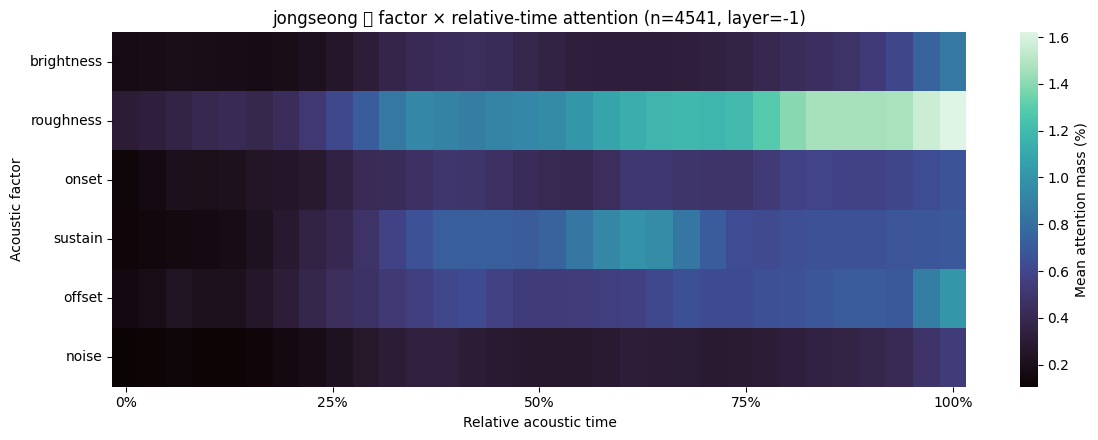

,0.000000,0.032258,0.064516,0.096774,0.129032,0.161290,0.193548,0.225806,0.258065,0.290323,...,0.709677,0.741935,0.774194,0.806452,0.838710,0.870968,0.903226,0.935484,0.967742,1.000000
brightness,0.168730,0.177816,0.189831,0.185889,0.179256,0.170353,0.186531,0.212553,0.255403,0.310935,...,0.337068,0.357894,0.390863,0.420290,0.447420,0.476968,0.526613,0.594110,0.743504,0.848166
roughness,0.304290,0.326397,0.358151,0.391659,0.409201,0.384133,0.432068,0.513198,0.602743,0.709504,...,1.180901,1.203436,1.288066,1.395994,1.465363,1.461073,1.463595,1.475881,1.561072,1.620783
onset,0.126286,0.158672,0.200696,0.197648,0.211589,0.243590,0.250339,0.271224,0.342719,0.413477,...,0.482008,0.482876,0.525297,0.578146,0.588954,0.574748,0.576847,0.591067,0.633692,0.663739
sustain,0.133666,0.139770,0.148511,0.159746,0.181789,0.220085,0.279523,0.350803,0.396004,0.474882,...,0.709259,0.633570,0.619706,0.643690,0.656677,0.656300,0.661677,0.668356,0.681603,0.689258
offset,0.157784,0.185257,0.227383,0.210197,0.211283,0.253977,0.308134,0.383037,0.437173,0.471915,...,0.625630,0.621690,0.644329,0.659286,0.684462,0.707301,0.706476,0.694803,0.875260,1.008702
noise,0.105164,0.115969,0.127190,0.113577,0.113578,0.129323,0.152830,0.180179,0.222611,0.264987,...,0.286353,0.289055,0.304889,0.325165,0.344802,0.359053,0.379853,0.408342,0.483468,0.535390


In [ ]:
plot_jamo_factor_time_attention(category='jongseong', jamo="ㄱ")